## Probability and Statistics

In [1]:
import numpy as np

data = [5,6,6,7,7,7,8,8,9,10,12]

mean     = np.mean(data)          
median   = np.median(data)        
std      = np.std(data)           
variance = np.var(data)           

In [2]:
print(mean)

7.7272727272727275


In [3]:
print(median)

7.0


In [4]:
print(variance)

3.652892561983471


In [5]:
print(std)

1.9112541856026035


   P(A|B)  = P(A∩B) / P(B)        ← conditional
   
   Bayes   = P(B|A)×P(A) / P(B)   ← update belief with evidence

#### Normal Distribution → "What values are likely?"

#### Uniform Distribution → "Everything is equally likely."

#### Binomial Distribution → "How many successes will I get?"

### Normal Distribution

- famous bell curve shape

##### Real-world examples

- Human heights
  
- Exam scores

- Sensor noise

- Neural network weight initialization

#### Generate Samples

In [6]:
import numpy as np

# Standard Normal (mean=0, std=1)
samples = np.random.randn(1000)

print(samples[:5])

[ 0.20542841 -1.08206339  0.57453916 -0.76489968  0.74879002]


#### Using sciPy

In [7]:
from scipy import stats

# Normal Distribution
dist = stats.norm(loc=0, scale=1)

# Probability density at x=0
print(dist.pdf(0))

# Cumulative probability P(X <= 1.96)
print(dist.cdf(1.96))

0.3989422804014327
0.9750021048517795


#### Plot

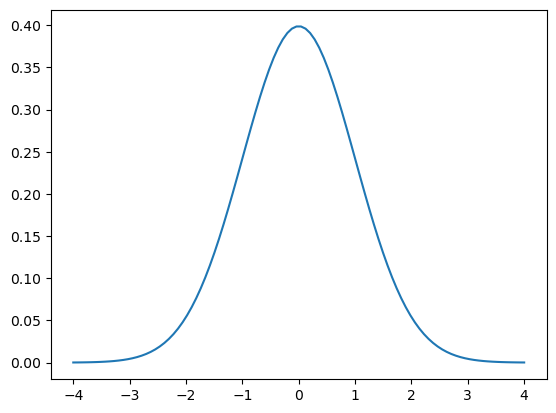

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 100)
y = stats.norm.pdf(x)

plt.plot(x, y)
plt.show()

### Uniform Distribution

- Every value has equal probability.

##### Real-world examples

- Rolling a fair die

- Random initialization

- Dropout masks

- Random simulations

#### Generate Samples

In [9]:
import numpy as np

samples = np.random.uniform(
    low=0,
    high=1,
    size=1000
)

print(samples[:5])

[0.04423319 0.21973104 0.71289411 0.27778822 0.43482845]


#### Using sciPy

In [10]:
from scipy import stats

dist = stats.uniform(loc=0, scale=1)

print(dist.pdf(0.5))

1.0


#### Plot

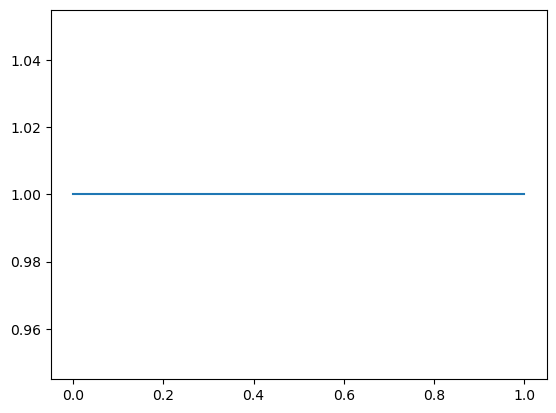

In [11]:
x = np.linspace(0, 1, 100)
y = stats.uniform.pdf(x)

plt.plot(x, y)
plt.show()

### Binomial Distribution

- Counts the number of successes in n independent trials.

##### Real-world Examples

- Number of heads in coin flips

- Email spam/not spam

- Disease positive/negative

- Binary classification

#### Generate Samples

In [12]:
import numpy as np

samples = np.random.binomial(
    n=10,
    p=0.5,
    size=1000
)

print(samples[:10])

[4 4 6 3 8 4 5 5 4 6]


#### Using sciPy

In [13]:
from scipy import stats

dist = stats.binom(n=10, p=0.5)

print(dist.pmf(7))

0.11718749999999999


#### Cummulative Probabilty

In [14]:
print(dist.cdf(7))

0.9453125


#### Plot

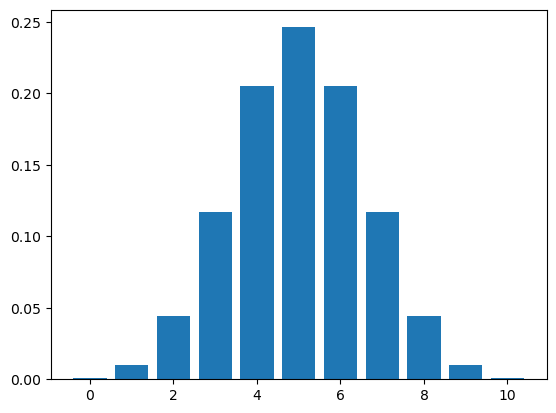

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import binom

x = range(11)
y = binom.pmf(x, n=10, p=0.5)

plt.bar(x, y)
plt.show()

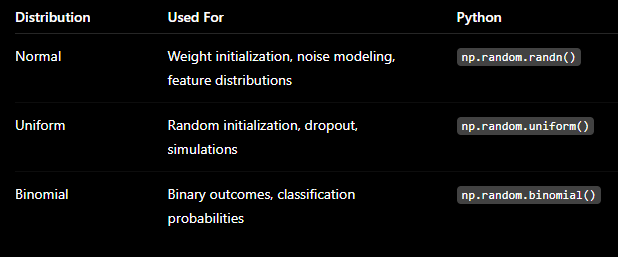

## Cross-Entropy Loss

- "How much should I punish the model for the probability it assigned to the correct answer?"

In [16]:
import numpy as np

# True label: Cat
# Classes = [Dog, Cat, Bird]
y_true = np.array([0, 1, 0])

# Model probabilities
y_pred = np.array([0.1, 0.8, 0.1])

# Cross-Entropy Loss
loss = -np.sum(y_true * np.log(y_pred + 1e-9))

print(f"Loss: {loss:.3f}")

Loss: 0.223


#### Softmax 

- think as a score-to-probability converter

Softmax converts a model's raw scores into probabilities that add up to 100%, making the predictions easy to interpret and compare.

In [17]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x))  # Numerical stability
    return e_x / e_x.sum()

# Raw scores from a neural network
scores = np.array([2.0, 1.0, 0.1])

# Convert to probabilities
probs = softmax(scores)

print("Scores:", scores)
print("Probabilities:", probs)
print("Sum:", probs.sum())

Scores: [2.  1.  0.1]
Probabilities: [0.65900114 0.24243297 0.09856589]
Sum: 1.0


### Softmax + Cross Entropy

In [18]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

# Raw scores (logits)
scores = np.array([2.0, 1.0, 0.1])

# Convert to probabilities
probs = softmax(scores)

# True class = Class 0
y_true = np.array([1, 0, 0])

# Cross Entropy Loss
loss = -np.sum(y_true * np.log(probs + 1e-9))

print("Probabilities:", probs)
print("Loss:", round(loss, 3))

Probabilities: [0.65900114 0.24243297 0.09856589]
Loss: 0.417


### Correlation

- It answers one simple question "When one variable changes, does the other tend to change too?"

In [19]:
import numpy as np

# Study hours
x = np.array([1, 2, 3, 4, 5])

# Exam scores
y = np.array([2, 4, 5, 4, 5])

correlation = np.corrcoef(x, y)[0, 1]

print("Correlation:", round(correlation, 2))

Correlation: 0.77


#### Correlation ≠ Causation

- This is one of the most important ideas in ML and Data Science.

## Correlation

Means:

Two things move together.

## Causation

Means:

One thing directly causes the other.

- These are NOT the same.

- Correlation tells you what moves together.

- Causation tells you what causes what.

#### A machine learning model can learn correlation, but it does not automatically understand causation.

## Project to Build Cross-Entropy from scrtach

In [20]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def cross_entropy_loss(y_true, y_pred_raw):
    probs = softmax(y_pred_raw)
    # clip to avoid log(0)
    probs = np.clip(probs, 1e-9, 1.0)
    return -np.sum(y_true * np.log(probs))

# 3-class problem (cat / dog / bird)
y_true     = np.array([0, 1, 0])   # true label: dog
good_pred  = np.array([0.1, 3.0, 0.2])  # model is confident it's dog
bad_pred   = np.array([2.0, 0.5, 1.5])  # model thinks it's a cat

print("Good prediction loss:", round(cross_entropy_loss(y_true, good_pred), 4))
print("Bad prediction loss: ", round(cross_entropy_loss(y_true, bad_pred), 4))
# Good: ~0.18   Bad: ~1.88  → higher loss = more wrong

Good prediction loss: 0.1096
Bad prediction loss:  2.1041


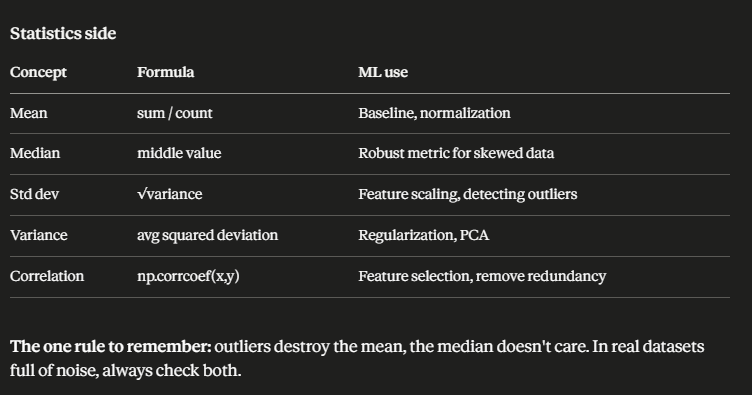

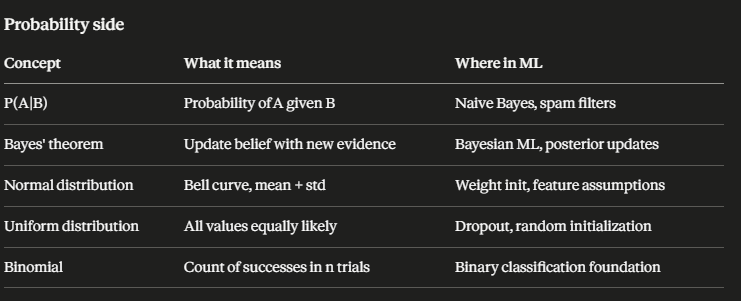